In [11]:
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Literal
from operator import add
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver


In [2]:
load_dotenv()
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]


In [3]:
model=ChatOpenAI()

def chat_node(state:ChatState):
    #messages
    message=state['messages']

    #response
    response=model.invoke(message)
    #storing the response
    return {'messages':[response]}


In [4]:
graph=StateGraph(ChatState)

#adding a nodes

graph.add_node("Chat_node",chat_node)

#adding an edges
graph.add_edge(START,"Chat_node")
graph.add_edge("Chat_node",END)

chatmodel=graph.compile()

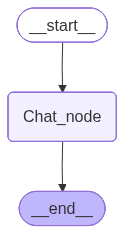

In [5]:
chatmodel

In [6]:
initial_state={'messages':[HumanMessage(content="what is capital of South Africa")]}
chatmodel.invoke(initial_state)

{'messages': [HumanMessage(content='what is capital of South Africa', additional_kwargs={}, response_metadata={}, id='f6d55435-6100-4d8d-bbc9-fa64ba614523'),
  AIMessage(content='The capital of South Africa is Pretoria.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 13, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DV82ykWDzKfa9AHOHcSdNxB7SMCng', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d946a-0726-7411-800f-dcc21668fdc0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 9, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'ou

In [ ]:
#it can not recall the messages from previous chat however we have already created class to add the message(mean in memory)
#reason for this is invoking in every loop : which can solve by persistent
while True:
    user_message=input("How may i help you Next?")
    print(user_message)
    if user_message.strip().lower() in ('exit','bye','quit'):
        break
    response=chatmodel.invoke({'messages':[HumanMessage(content=user_message)]})
    print("AI Message:",response['messages'][-1].content)

what is IPL ?
AI Message: IPL stands for Indian Premier League. It is a professional Twenty20 cricket league in India, which is contested by various franchise teams representing different cities in the country. The league was founded by the Board of Control for Cricket in India (BCCI) in 2007 and has quickly become one of the most popular and lucrative cricket tournaments in the world.
who established it and which country 
AI Message: The United Nations was established on October 24, 1945 by 51 countries, including the United States, United Kingdom, China, and the Soviet Union.
who established the IPL and origin country
AI Message: The Indian Premier League (IPL) was established by the Board of Control for Cricket in India (BCCI) in India. The first season of the IPL was held in 2008.
bye


# What happen whenever we invoke the model then its purge all the data from state. to store this, we use persistent

In [13]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)

#adding a nodes

graph.add_node("Chat_node",chat_node)

#adding an edges
graph.add_edge(START,"Chat_node")
graph.add_edge("Chat_node",END)

chatmodel=graph.compile(checkpointer)

In [14]:
thread_id='1'
while True:
    user_message=input("How may i help you Next?")
    print(user_message)
    if user_message.strip().lower() in ('exit','bye','quit'):
        break
    config={'configurable':{'thread_id':thread_id}}
    response=chatmodel.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print("AI Message:",response['messages'][-1].content)

i am deepak 
AI Message: Nice to meet you Deepak! How can I assist you today?
who am i?
AI Message: You are Deepak, a unique individual with your own thoughts, feelings, and experiences.
what is IP?
AI Message: IP stands for Internet Protocol. It is a set of rules that governs the format of data sent over the internet or a network. IP addresses are unique identifiers assigned to devices connected to a network that allow them to communicate with each other.
who invented this
AI Message: The Internet Protocol (IP) was developed in the 1970s by computer scientists Vint Cerf and Bob Kahn, who are considered to be the "fathers of the Internet". They played a key role in developing the TCP/IP protocol suite, which includes the Internet Protocol that enables computers to communicate over a network.
okay bye
AI Message: Goodbye! Have a great day, Deepak!
bye


In [16]:
chatmodel.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='i am deepak ', additional_kwargs={}, response_metadata={}, id='ef6fcddb-1a84-4e7c-8743-7aa0bbf4da0d'), AIMessage(content='Nice to meet you Deepak! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 12, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DV8p47hqOse34NkLf6vkfXEyPVWJy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9497-8b64-7440-bb54-d08e94e9b77a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 14, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_